# Fractal Analysis attempt
## Pre-processing and tests

In [1]:
import nibabel as nib
import numpy as np
import math, random
import sklearn.metrics as skl

In [5]:
### NIFTI IMAGE LOADING ###

image_path = "../001/mri/orig/001.nii.gz"
img = nib.load(image_path)
nii_header = img.header
imageloaded = img.get_fdata()
imageloaded.shape

(256, 256, 150)

In [6]:
# vox_center = (np.array(imageloaded.shape) - 1) / 2.
# print(vox_center)
# nib.affines.apply_affine(img.affine, vox_center)

In [7]:
# np.set_printoptions(precision=3, suppress=True)
# img.affine

In [8]:
# list(nii_header)

In [9]:
# nii_header['pixdim']

In [10]:
### CHECK THE IMAGE ISOTROPY ###
voxels_size = nii_header['pixdim'][1:4]
print(f'The voxel size is {voxels_size[0]} x {voxels_size[1]} x {voxels_size[2]} mm^3')

The voxel size is 0.9375 x 0.9375 x 1.1999969482421875 mm^3


In [11]:
### COMPUTING THE MINIMUM AND MAXIMUM SIZES OF THE IMAGE ###
L_min = min(imageloaded.shape)
print(f'Shape of the image : {imageloaded.shape}')
print(f'The minimum size of the image is {L_min} mm')
Lx=imageloaded.shape[0]
Ly=imageloaded.shape[1]
Lz=imageloaded.shape[2]
L_Max = max(imageloaded.shape)
print(f'The maximum size of the image is {L_Max} mm')


# Realx=imageloaded.shape[0] * voxels_size[0]
# Realy=imageloaded.shape[1] * voxels_size[1]
# Realz=imageloaded.shape[2] * voxels_size[2]
# print("True size")
# print(Realx,Realy,Realz)

Shape of the image : (256, 256, 150)
The minimum size of the image is 150 mm
The maximum size of the image is 256 mm


In [12]:
### NON-ZERO VOXELS OF THE IMAGE: NUMBER AND Y, X, Z COORDINATES ###
voxels=[]
for i in range(Lx):
    for j in range(Ly):
        for k in range(Lz):
            if imageloaded[i,j,k]>0:
                voxels.append((i,j,k))
voxels=np.asarray(voxels)
print(f'The non-zero voxels in the image are (the image volume) {voxels.shape[0]} / {math.prod(imageloaded.shape)}')

The non-zero voxels in the image are (the image volume) 5589073 / 9830400


## Fractal Analysis

In [13]:
### LOGARITHM SCALES VECTOR AND COUNTS VECTOR CREATION ###
Ns = []
scales = []
stop = math.ceil(math.log2(L_Max))
for exp in range(stop+1):
    scales.append(2**exp)
scales = np.asarray(scales)
random.seed(1)
scales

array([  1,   2,   4,   8,  16,  32,  64, 128, 256])

In [14]:
# np.arange(4,150,128)

In [12]:
### THE 3D BOX-COUNTING ALGORITHM WITH 20 PSEUDO-RANDOM OFFSETS ###
for scale in scales[:1]:
    print(f'Computing scale {scale}...')
    Ns_offset=[] 
    for i in range(20): 
        y0_rand = -random.randint(0,scale)
        yend_rand = Ly+1+scale
        x0_rand = -random.randint(0,scale)
        xend_rand = Lx+1+scale
        z0_rand = -random.randint(0,scale)
        zend_rand = Lz+1+scale
        # computing the 3D histogram
        H, edges=np.histogramdd(voxels, bins=(np.arange(y0_rand,yend_rand,scale), np.arange(x0_rand,xend_rand,scale), np.arange(z0_rand,zend_rand,scale)))
        Ns_offset.append(np.sum(H>0))
        print(f'======= Offset {i+1}: x0_rand = {x0_rand}, y0_rand = {y0_rand}, z0_rand = {z0_rand}, count = {np.sum(H>0)}')
    Ns.append(np.mean(Ns_offset))

Computing scale 1...
======= Offset 1: x0_rand = 0, y0_rand = 0, z0_rand = -1, count = 5589073
======= Offset 2: x0_rand = -1, y0_rand = 0, z0_rand = -1, count = 5589073
======= Offset 3: x0_rand = -1, y0_rand = -1, z0_rand = 0, count = 5589073
======= Offset 4: x0_rand = -1, y0_rand = 0, z0_rand = 0, count = 5589073
======= Offset 5: x0_rand = -1, y0_rand = -1, z0_rand = 0, count = 5589073
======= Offset 6: x0_rand = -1, y0_rand = -1, z0_rand = 0, count = 5589073
======= Offset 7: x0_rand = -1, y0_rand = 0, z0_rand = 0, count = 5589073
======= Offset 8: x0_rand = 0, y0_rand = 0, z0_rand = 0, count = 5589073
======= Offset 9: x0_rand = 0, y0_rand = -1, z0_rand = -1, count = 5589073
======= Offset 10: x0_rand = 0, y0_rand = 0, z0_rand = -1, count = 5589073
======= Offset 11: x0_rand = 0, y0_rand = -1, z0_rand = -1, count = 5589073
======= Offset 12: x0_rand = 0, y0_rand = 0, z0_rand = -1, count = 5589073
======= Offset 13: x0_rand = 0, y0_rand = -1, z0_rand = -1, count = 5589073
=======

In [ ]:
H.shape

In [ ]:
# Create a 3D plot
import matplotlib.pyplot as plt 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get the coordinates of non-empty boxes
y, x, z = np.where(H > 0)

# Plot the non-empty boxes
ax.scatter(x, y, z, c=H[y, x, z], cmap='viridis', s=100*H[y, x, z]/np.max(H))

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'3D Box-Counting Histogram (Scale: {scale}, Offset: {i+1})')

# Add a colorbar
cbar = plt.colorbar(ax.scatter(x, y, z, c=H[y, x, z], cmap='viridis'))
cbar.set_label('Box Count')

plt.tight_layout()
plt.show()

In [15]:
Ns

[5589073.0]

In [17]:
### AUTOMATED SELECTION OF THE FRACTAL SCALING WINDOW ### 
minWindowSize = 5 # in the logarithm scale, in the worst case, 5 points cover more than 1.2 decades, which should be the minimum fractal scaling window possible, to define an object as fractal (Marzi et al., Scientific Reports 2020)
scales_indices = [] 

for step in range(scales.size, minWindowSize-1, -1):
    for start_index in range(0, scales.size-step+1):
        scales_indices.append((start_index, start_index+step-1))
scales_indices = np.asarray(scales_indices)    

k_ind = 1 # number of indipendent variables in the regression model
R2_adj = -1
for k in range(scales_indices.shape[0]):
    coeffs=np.polyfit(np.log2(scales)[scales_indices[k,0]:scales_indices[k,1] + 1], np.log2(Ns)[scales_indices[k,0]:scales_indices[k,1] + 1], 1)
    n = scales_indices[k,1] - scales_indices[k,0] + 1 
    y_true = np.log2(Ns)[scales_indices[k,0]:scales_indices[k,1] + 1]
    y_pred = np.polyval(coeffs,np.log2(scales)[scales_indices[k,0]:scales_indices[k,1] + 1])
    R2=skl.r2_score(y_true,y_pred)
    R2_adj_tmp = 1 - (1 - R2)*((n - 1)/(n - (k_ind + 1)))
    print(f'In the interval [{scales[scales_indices[k,0]]}, {scales[scales_indices[k,1]]}] voxels, the FD is {-coeffs[0]} and the determination coefficient adjusted for the number of points is {R2_adj_tmp}')
    R2_adj = round(R2_adj, 3)
    R2_adj_tmp = round(R2_adj_tmp, 3)
    if R2_adj_tmp > R2_adj:
        R2_adj = R2_adj_tmp
        FD = -coeffs[0]
        mfs = scales[scales_indices[k,0]]
        Mfs = scales[scales_indices[k,1]]
        fsw_index = k
        coeffs_selected = coeffs
    FD = round(FD, 4)

TypeError: expected x and y to have same length

In [ ]:
### FRACTAL ANALYSIS RESULTS ###
mfs = mfs * L_min
Mfs = Mfs * L_min
# print(f'The mfs automatically selected is {mfs}')
# print(f'The Mfs automatically selected is {Mfs}')
# print(f'The FD automatically selected is {FD}')
# print(f'The R2_adj is {R2_adj}')
print("mfs automatically selected:", mfs)
print("Mfs automatically selected:", Mfs)
print("FD automatically selected:", FD)

mfs automatically selected: 150
Mfs automatically selected: 9600
FD automatically selected: 2.6995


## Repeat process of right vs left
after translating from freesurfer.ipynb

In [ ]:
def fractal_analysis(volume_path):
    ### NIFTI IMAGE LOADING ###
    image_path = volume_path
    img = nib.load(image_path)
    nii_header = img.header
    imageloaded = img.get_fdata()
    imageloaded.shape
    ### CHECK THE IMAGE ISOTROPY ###
    voxels_size = nii_header['pixdim'][1:4]
    print(f'The voxel size is {voxels_size[0]} x {voxels_size[1]} x {voxels_size[2]} mm^3')
    ### COMPUTING THE MINIMUM AND MAXIMUM SIZES OF THE IMAGE ###
    L_min = voxels_size[0]
    print(f'Shape of the image : {imageloaded.shape}')
    print(f'The minimum size of the image is {L_min} mm')
    Ly=imageloaded.shape[0]
    Lx=imageloaded.shape[1]
    Lz=imageloaded.shape[2]
    if Lx > Ly:
        L_Max = Lx
    else:
        L_Max = Ly
    if Lz > L_Max:
        L_Max = Lz
    print(f'The maximum size of the image is {L_Max} mm')
    ### NON-ZERO VOXELS OF THE IMAGE: NUMBER AND Y, X, Z COORDINATES ###
    voxels=[]
    for i in range(Ly):
        for j in range(Lx):
            for k in range(Lz):
                if imageloaded[i,j,k]>0:
                    voxels.append((i,j,k))
    voxels=np.asarray(voxels)
    print(f'The non-zero voxels in the image are (the image volume) {voxels.shape[0]} / {math.prod(imageloaded.shape)}')
    ### LOGARITHM SCALES VECTOR AND COUNTS VECTOR CREATION ###
    Ns = []
    scales = []
    stop = math.ceil(math.log2(L_Max))
    for exp in range(stop+1):
        scales.append(2**exp)
    scales = np.asarray(scales)
    random.seed(1)
    ### THE 3D BOX-COUNTING ALGORITHM WITH 20 PSEUDO-RANDOM OFFSETS ###
    for scale in scales:
        print(f'Computing scale {scale}...')
        Ns_offset=[] 
        for i in range(20): 
            y0_rand = -random.randint(0,scale)
            yend_rand = Ly+1+scale
            x0_rand = -random.randint(0,scale)
            xend_rand = Lx+1+scale
            z0_rand = -random.randint(0,scale)
            zend_rand = Lz+1+scale
            # computing the 3D histogram
            H, edges=np.histogramdd(voxels, bins=(np.arange(y0_rand,yend_rand,scale), np.arange(x0_rand,xend_rand,scale), np.arange(z0_rand,zend_rand,scale)))
            Ns_offset.append(np.sum(H>0))
            print(f'======= Offset {i+1}: x0_rand = {x0_rand}, y0_rand = {y0_rand}, z0_rand = {z0_rand}, count = {np.sum(H>0)}')
        Ns.append(np.mean(Ns_offset))
    ### AUTOMATED SELECTION OF THE FRACTAL SCALING WINDOW ### 
    minWindowSize = 5 # in the logarithm scale, in the worst case, 5 points cover more than 1.2 decades, which should be the minimum fractal scaling window possible, to define an object as fractal (Marzi et al., Scientific Reports 2020)
    scales_indices = [] 

    for step in range(scales.size, minWindowSize-1, -1):
        for start_index in range(0, scales.size-step+1):
            scales_indices.append((start_index, start_index+step-1))
    scales_indices = np.asarray(scales_indices)    

    k_ind = 1 # number of indipendent variables in the regression model
    R2_adj = -1
    for k in range(scales_indices.shape[0]):
        coeffs=np.polyfit(np.log2(scales)[scales_indices[k,0]:scales_indices[k,1] + 1], np.log2(Ns)[scales_indices[k,0]:scales_indices[k,1] + 1], 1)
        n = scales_indices[k,1] - scales_indices[k,0] + 1 
        y_true = np.log2(Ns)[scales_indices[k,0]:scales_indices[k,1] + 1]
        y_pred = np.polyval(coeffs,np.log2(scales)[scales_indices[k,0]:scales_indices[k,1] + 1])
        R2=skl.r2_score(y_true,y_pred)
        R2_adj_tmp = 1 - (1 - R2)*((n - 1)/(n - (k_ind + 1)))
        print(f'In the interval [{scales[scales_indices[k,0]]}, {scales[scales_indices[k,1]]}] voxels, the FD is {-coeffs[0]} and the determination coefficient adjusted for the number of points is {R2_adj_tmp}')
        R2_adj = round(R2_adj, 3)
        R2_adj_tmp = round(R2_adj_tmp, 3)
        if R2_adj_tmp > R2_adj:
            R2_adj = R2_adj_tmp
            FD = -coeffs[0]
            mfs = scales[scales_indices[k,0]]
            Mfs = scales[scales_indices[k,1]]
            fsw_index = k
            coeffs_selected = coeffs
        FD = round(FD, 4)
    ### FRACTAL ANALYSIS RESULTS ###
    mfs = mfs * L_min
    Mfs = Mfs * L_min
    print("mfs automatically selected:", mfs)
    print("Mfs automatically selected:", Mfs)
    print("FD automatically selected:", FD)

In [17]:
fractal_analysis("../001/mri/orig/001.nii.gz")

The voxel size is 0.9375 x 0.9375 x 1.1999969482421875 mm^3
Shape of the image : (256, 256, 150)
The minimum size of the image is 0.9375 mm
The maximum size of the image is 256 mm
The non-zero voxels in the image are (the image volume) 5589073 / 9830400
Computing scale 1...
======= Offset 1: x0_rand = 0, y0_rand = 0, z0_rand = -1, count = 5589073
======= Offset 2: x0_rand = -1, y0_rand = 0, z0_rand = -1, count = 5589073
======= Offset 3: x0_rand = -1, y0_rand = -1, z0_rand = 0, count = 5589073
======= Offset 4: x0_rand = -1, y0_rand = 0, z0_rand = 0, count = 5589073
======= Offset 5: x0_rand = -1, y0_rand = -1, z0_rand = 0, count = 5589073
======= Offset 6: x0_rand = -1, y0_rand = -1, z0_rand = 0, count = 5589073
======= Offset 7: x0_rand = -1, y0_rand = 0, z0_rand = 0, count = 5589073
======= Offset 8: x0_rand = 0, y0_rand = 0, z0_rand = 0, count = 5589073
======= Offset 9: x0_rand = 0, y0_rand = -1, z0_rand = -1, count = 5589073
======= Offset 10: x0_rand = 0, y0_rand = 0, z0_rand = 

In [18]:
fractal_analysis("../rh.nii.gz")

FileNotFoundError: No such file or no access: '../rh.nii.gz'

In [ ]:
fractal_analysis("../lh.nii.gz")

In [ ]:
fractal_analysis("../lh.nii.gz")

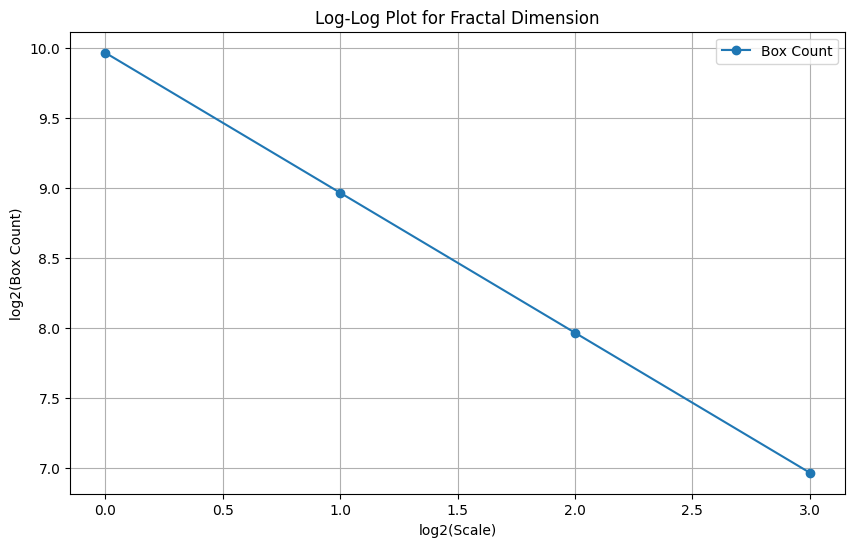

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
scales = np.array([1, 2, 4, 8])
Ns = np.array([1000, 500, 250, 125])

# Log-log plot
plt.figure(figsize=(10, 6))
plt.plot(np.log2(scales), np.log2(Ns), 'o-', label='Box Count')
plt.title('Log-Log Plot for Fractal Dimension')
plt.xlabel('log2(Scale)')
plt.ylabel('log2(Box Count)')
plt.grid(True)
plt.legend()
plt.show()